# UCI Air Quality Dataset – Models and Analytics Intelligence Evaluation

This notebook investigates the UCI Air Quality Dataset from Italy and evaluates its suitability for the Intelligent IoT Data Management project.

The work covers ML-001 Dataset Hunting and MVP Relevance and ML-002 Data Scientist Evaluation of Models and Analytics Intelligence (AIntl).

# ML-001 – Dataset Hunting and MVP Relevance

## Dataset Selection and Relevance

### Dataset Name and Source

The selected dataset is the **Air Quality Dataset** from the UCI Machine Learning Repository. It contains real-world air quality measurements collected from a multisensor monitoring device in an Italian city. The dataset provides hourly measurements of different air pollutants, chemical sensor responses, temperature and humidity.

### Domain / Topic

The dataset belongs to the **environmental monitoring and IoT sensor** domain. It represents air quality conditions measured over time using multiple sensors and reference measurements.

### Why I Selected This Dataset

I selected this dataset because it contains realistic time-series sensor data from a domain different from the NAB dataset currently used by the project. It contains several numeric sensor variables together with date and time information. This makes it suitable for testing whether the current Models and Analytics Integration (AIntl) pipeline can work with real-world environmental IoT data.

## Initial Dataset Loading and Inspection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(
    "AirQualityUCI.csv",
    sep=";",
    decimal=","
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
Date
Time
CO(GT)
PT08.S1(CO)
NMHC(GT)
C6H6(GT)
PT08.S2(NMHC)
NOx(GT)
PT08.S3(NOx)
NO2(GT)
PT08.S4(NO2)
PT08.S5(O3)
T
RH
AH
Unnamed: 15
Unnamed: 16


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


### Main Variables Available

The dataset contains several useful numeric variables, including:

- `CO(GT)` – carbon monoxide reference measurement
- `PT08.S1(CO)` – CO-related sensor response
- `NMHC(GT)` – non-methane hydrocarbon measurement
- `C6H6(GT)` – benzene measurement
- `PT08.S2(NMHC)` – NMHC-related sensor response
- `NOx(GT)` – nitrogen oxides measurement
- `PT08.S3(NOx)` – NOx-related sensor response
- `NO2(GT)` – nitrogen dioxide measurement
- `PT08.S4(NO2)` – NO2-related sensor response
- `PT08.S5(O3)` – O3-related sensor response
- `T` – temperature
- `RH` – relative humidity
- `AH` – absolute humidity

The dataset also contains separate `Date` and `Time` fields, which can be combined into a timestamp for time-series analysis.

## Initial Data Quality Preparation

In [7]:
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"])

In [8]:
print("Shape after removing empty columns:", df.shape)
df.head()

Shape after removing empty columns: (9471, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [9]:
df = df.dropna(how="all").copy()

In [10]:
print("Shape after removing empty rows:", df.shape)

Shape after removing empty rows: (9357, 15)


In [11]:
minus_200_counts = (df == -200).sum()


In [12]:
print("Number of -200 values in each column:")
print(minus_200_counts)

Number of -200 values in each column:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [13]:
minus_200_percentage=((df==-200).sum()/len(df)*100).round(2)

missing_marker_summary=pd.DataFrame({
    "Count_-200":minus_200_counts,
    "Percentage":minus_200_percentage
})
missing_marker_summary

,Count_-200,Percentage
Date,0,0.00
Time,0,0.00
CO(GT),1683,17.99
PT08.S1(CO),366,3.91
NMHC(GT),8443,90.23
C6H6(GT),366,3.91
PT08.S2(NMHC),366,3.91
NOx(GT),1639,17.52
PT08.S3(NOx),366,3.91
NO2(GT),1642,17.55


In [14]:
df.replace(-200, np.nan, inplace=True)

In [15]:
print("Missing values after converting -200 to NaN:")
print(df.isnull().sum())

Missing values after converting -200 to NaN:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [16]:
df["timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

print("Invalid timestamps:", df["timestamp"].isnull().sum())
print("First timestamp:", df["timestamp"].min())
print("Last timestamp:", df["timestamp"].max())

df[["Date", "Time", "timestamp"]].head()

Invalid timestamps: 0
First timestamp: 2004-03-10 18:00:00
Last timestamp: 2005-04-04 14:00:00


,Date,Time,timestamp
0,10/03/2004,18.00.00,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2004-03-10 21:00:00
4,10/03/2004,22.00.00,2004-03-10 22:00:00


In [17]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

Duplicate rows: 0
Duplicate timestamps: 0


## Dataset Suitability for Project Analytics

### Potential Anomaly Detection Use

The multiple sensor measurements make the dataset suitable for Isolation Forest. The detector can be used to identify observations where air-quality and environmental sensor readings are unusual compared with normal behaviour in the dataset.

Possible unusual behaviour may include sudden changes in pollutant sensor responses, unusual combinations of sensor measurements, or environmental readings that differ strongly from surrounding observations.

### Potential Correlation Use

The dataset contains several variables that can be meaningfully compared through correlation. Examples include:

- `CO(GT)` and `PT08.S1(CO)`
- `NOx(GT)` and `PT08.S3(NOx)`
- `NO2(GT)` and `PT08.S4(NO2)`
- Temperature (`T`) and relative humidity (`RH`)
- Temperature (`T`) and absolute humidity (`AH`)

These relationships make the dataset suitable for testing the correlation path of the Analytics Integration pipeline.

### Relevance to the IoT Analytics MVP

Testing this dataset can help determine whether the current IoT Analytics MVP works with realistic environmental sensor data rather than only the existing development and NAB datasets.

A successful test would provide evidence that the Models/AIntl pipeline can accept, process and analyse time-series information from another IoT domain. The experiment can also identify preprocessing requirements, limitations and areas where the current system may need improvement when handling real-world data.

# ML-002 – Data Scientist Evaluation of Models and AIntl

## 1. Data Integrity and Exploratory Analysis

Before running the dataset through the Models/AIntl pipeline, the dataset is investigated to understand its structure, quality and preprocessing requirements.

In [18]:
print("Number of observations:", len(df))
print("Number of columns:", len(df.columns))
print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print(df["timestamp"].min(), "to", df["timestamp"].max())

Number of observations: 9357
Number of columns: 16

Data types:
Date                     object
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
timestamp        datetime64[ns]
dtype: object

Date range:
2004-03-10 18:00:00 to 2005-04-04 14:00:00


In [19]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.152750,1.453252,0.1000,1.1000,1.8000,2.9000,11.900
PT08.S1(CO),8991.0,1099.833166,217.080037,647.0000,937.0000,1063.0000,1231.0000,2040.000
NMHC(GT),914.0,218.811816,204.459921,7.0000,67.0000,150.0000,297.0000,1189.000
C6H6(GT),8991.0,10.083105,7.449820,0.1000,4.4000,8.2000,14.0000,63.700
PT08.S2(NMHC),8991.0,939.153376,266.831429,383.0000,734.5000,909.0000,1116.0000,2214.000
NOx(GT),7718.0,246.896735,212.979168,2.0000,98.0000,180.0000,326.0000,1479.000
PT08.S3(NOx),8991.0,835.493605,256.817320,322.0000,658.0000,806.0000,969.5000,2683.000
NO2(GT),7715.0,113.091251,48.370108,2.0000,78.0000,109.0000,142.0000,340.000
PT08.S4(NO2),8991.0,1456.264598,346.206794,551.0000,1227.0000,1463.0000,1674.0000,2775.000
PT08.S5(O3),8991.0,1022.906128,398.484288,221.0000,731.5000,963.0000,1273.5000,2523.000


In [20]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Percentage", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
PT08.S1(CO),366,3.91
PT08.S2(NMHC),366,3.91
C6H6(GT),366,3.91
PT08.S3(NOx),366,3.91
PT08.S4(NO2),366,3.91
PT08.S5(O3),366,3.91


In [21]:
sensor_columns = [
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH"
]

df[sensor_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
PT08.S1(CO),8991.0,1099.833166,217.080037,647.0000,937.0000,1063.0000,1231.0000,2040.000
PT08.S2(NMHC),8991.0,939.153376,266.831429,383.0000,734.5000,909.0000,1116.0000,2214.000
PT08.S3(NOx),8991.0,835.493605,256.817320,322.0000,658.0000,806.0000,969.5000,2683.000
PT08.S4(NO2),8991.0,1456.264598,346.206794,551.0000,1227.0000,1463.0000,1674.0000,2775.000
PT08.S5(O3),8991.0,1022.906128,398.484288,221.0000,731.5000,963.0000,1273.5000,2523.000
T,8991.0,18.317829,8.832116,-1.9000,11.8000,17.8000,24.4000,44.600
RH,8991.0,49.234201,17.316892,9.2000,35.8000,49.6000,62.5000,88.700
AH,8991.0,1.025530,0.403813,0.1847,0.7368,0.9954,1.3137,2.231


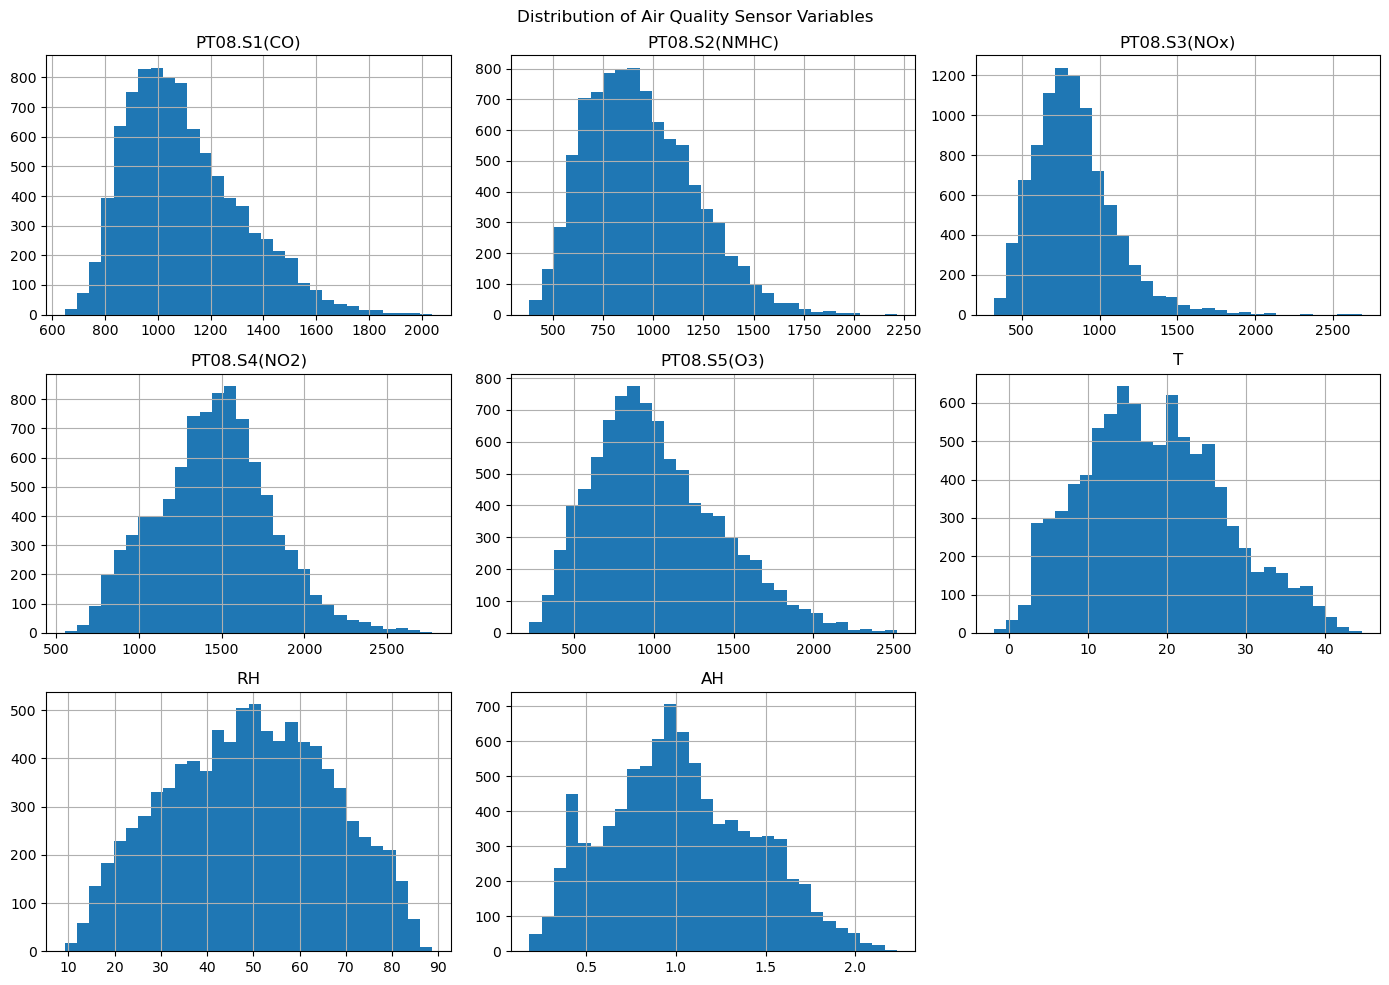

In [22]:
df[sensor_columns].hist(
    bins=30,
    figsize=(14, 10)
)

plt.suptitle("Distribution of Air Quality Sensor Variables")
plt.tight_layout()
plt.show()

In [23]:
correlation_matrix = df[sensor_columns].corr()

correlation_matrix.round(3)

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
PT08.S1(CO),1.000,0.893,-0.772,0.683,0.899,0.049,0.115,0.135
PT08.S2(NMHC),0.893,1.000,-0.797,0.777,0.881,0.241,-0.090,0.187
PT08.S3(NOx),-0.772,-0.797,1.000,-0.538,-0.797,-0.145,-0.057,-0.232
PT08.S4(NO2),0.683,0.777,-0.538,1.000,0.591,0.561,-0.032,0.630
PT08.S5(O3),0.899,0.881,-0.797,0.591,1.000,-0.027,0.125,0.071
T,0.049,0.241,-0.145,0.561,-0.027,1.000,-0.579,0.656
RH,0.115,-0.090,-0.057,-0.032,0.125,-0.579,1.000,0.168
AH,0.135,0.187,-0.232,0.630,0.071,0.656,0.168,1.000


## 2. Data Preprocessing for Models/AIntl

The initial investigation showed that the dataset contains missing measurements represented by the original value `-200`. These values were converted to `NaN` before analysis.

`NMHC(GT)` contains approximately 90% missing observations and is therefore not suitable for the main experiment. The reference measurements `CO(GT)`, `NOx(GT)` and `NO2(GT)` also contain considerably more missing data than the main sensor-response variables.

For the primary Models experiment, eight sensor and environmental variables are selected:

- PT08.S1(CO)
- PT08.S2(NMHC)
- PT08.S3(NOx)
- PT08.S4(NO2)
- PT08.S5(O3)
- T
- RH
- AH

These variables contain substantially fewer missing observations and provide multivariate information suitable for Isolation Forest. Rows with missing values in these selected variables are removed before pipeline execution so that missing values are not interpreted as anomalous sensor behaviour.

In [24]:
model_columns = [
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH"
]

model_df = df[
    ["timestamp"] + model_columns
].dropna().copy()

model_df = model_df.sort_values("timestamp").reset_index(drop=True)

print("Original observations:", len(df))
print("Observations after preprocessing:", len(model_df))
print("Rows removed:", len(df) - len(model_df))
print(
    "Percentage retained:",
    round(len(model_df) / len(df) * 100, 2),
    "%"
)

print("\nRemaining missing values:")
print(model_df.isnull().sum())

model_df.head()

Original observations: 9357
Observations after preprocessing: 8991
Rows removed: 366
Percentage retained: 96.09 %

Remaining missing values:
timestamp        0
PT08.S1(CO)      0
PT08.S2(NMHC)    0
PT08.S3(NOx)     0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


,timestamp,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888


In [25]:
time_differences = model_df["timestamp"].diff()

print("Most common time intervals:")
print(time_differences.value_counts().head())

print("\nLargest time gap:")
print(time_differences.max())

Most common time intervals:
timestamp
0 days 01:00:00    8974
0 days 02:00:00       3
0 days 04:00:00       1
1 days 01:00:00       1
0 days 15:00:00       1
Name: count, dtype: int64

Largest time gap:
3 days 05:00:00


In [26]:
print("Final Models input shape:", model_df.shape)
print("\nFinal data types:")
print(model_df.dtypes)

print("\nFinal numeric ranges:")
print(model_df[model_columns].agg(["min", "max"]).T)

Final Models input shape: (8991, 9)

Final data types:
timestamp        datetime64[ns]
PT08.S1(CO)             float64
PT08.S2(NMHC)           float64
PT08.S3(NOx)            float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

Final numeric ranges:
                    min       max
PT08.S1(CO)    647.0000  2040.000
PT08.S2(NMHC)  383.0000  2214.000
PT08.S3(NOx)   322.0000  2683.000
PT08.S4(NO2)   551.0000  2775.000
PT08.S5(O3)    221.0000  2523.000
T               -1.9000    44.600
RH               9.2000    88.700
AH               0.1847     2.231


## 3. Models/AIntl Pipeline Evaluation

After preprocessing, 8,991 observations (96.09% of the original valid records) remained for pipeline testing. The selected dataset contains five chemical sensor-response variables and three environmental variables.

Most consecutive observations remain separated by one hour. A small number of larger gaps are present because observations containing unavailable sensor readings were removed. The largest observed gap is 3 days and 5 hours. These gaps are retained rather than artificially interpolated so that the experiment remains based on observed sensor measurements.

The cleaned dataset is now prepared for testing with the existing Models/AIntl pipeline.

In [27]:
cleaned_output = "air_quality_clean.csv"

model_df.to_csv(
    cleaned_output,
    index=False
)

print("Cleaned dataset saved:", cleaned_output)
print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))

Cleaned dataset saved: air_quality_clean.csv
Rows: 8991
Columns: 9


## 3.1 Models Pipeline Evaluation – Isolation Forest

The cleaned real-world Air Quality dataset is first evaluated using the existing Models path. The objective is to determine whether the current Models implementation can validate and process a previously unseen environmental IoT dataset.

The experiment uses `PT08.S1(CO)` as the primary anomaly-detection variable. This variable represents the response of the tin-oxide sensor nominally targeted at carbon monoxide and contains 8,991 valid observations after preprocessing.

The existing Models path performs input validation, executes the Isolation Forest detector, converts the detector output through the Models Draft V0.1 adapter, and validates the resulting alerts against the shared analytics contract.

In [29]:
import sys
from pathlib import Path

repo_root = Path.cwd()

while not (repo_root / "analytics_integration").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)

from analytics_integration.pipeline import run_models_path

print("Models pipeline imported successfully.")

Repository root: d:\Team Project - B\github\Intelligent-IoT-Data-Management
Models pipeline imported successfully.


In [30]:
models_alerts, raw_model_result = run_models_path(
    df=model_df,
    timestamp_col="timestamp",
    model_metric="PT08.S1(CO)",
    entity_id="air_quality_italy",
    detector_name="isolationforest",
    detector_parameters={
        "contamination": 0.05,
        "n_estimators": 100,
        "random_state": 42
    }
)

print("Models pipeline completed successfully.")
print("Detector status:", raw_model_result["status"])
print("Total observations:", len(model_df))
print("Total anomaly alerts:", len(models_alerts))
print(
    "Anomaly percentage:",
    round(len(models_alerts) / len(model_df) * 100, 2),
    "%"
)

Models pipeline completed successfully.
Detector status: success
Total observations: 8991
Total anomaly alerts: 443
Anomaly percentage: 4.93 %


In [31]:
print("Raw detector result keys:")
print(raw_model_result.keys())

print("\nModel name:")
print(raw_model_result.get("model_name"))

print("\nRuntime:")
print(raw_model_result.get("runtime"))

print("\nNumber of anomaly flags:")
print(len(raw_model_result.get("anomaly_flag", [])))

print("\nNumber of anomaly scores:")
print(len(raw_model_result.get("score", [])))

Raw detector result keys:
dict_keys(['status', 'model_name', 'anomaly_flag', 'score', 'timestamp', 'runtime'])

Model name:
IsolationForest

Runtime:
0.16130638122558594

Number of anomaly flags:
8991

Number of anomaly scores:
8991


In [32]:
import json

print("First anomaly alert:\n")

if models_alerts:
    print(json.dumps(models_alerts[0], indent=4))
else:
    print("No anomaly alerts were generated.")

First anomaly alert:

{
    "timestamp": "2004-03-11T18:00:00Z",
    "alert_type": "POINTWISE_ANOMALY",
    "target": {
        "entity_id": "air_quality_italy",
        "metrics": [
            "PT08.S1(CO)"
        ]
    },
    "method": "IsolationForest",
    "score": 0.01131915800202532,
    "score_metadata": {
        "type": "raw_anomaly_score",
        "normalized": false
    },
    "severity": null,
    "message": "Anomaly detected in PT08.S1(CO) using IsolationForest.",
    "time_window": null,
    "supporting_values": {
        "runtime_ms": 161.306,
        "sensor_value": 1581.0
    },
    "source": {
        "component": "models"
    },
    "alert_id": null
}


## 3.2 Isolation Forest Results and Anomaly Analysis

The existing Models pipeline successfully processed all 8,991 preprocessed observations using `PT08.S1(CO)` as the selected anomaly-detection metric.

Isolation Forest generated 443 pointwise anomaly alerts, representing approximately 4.93% of the observations. The detector completed in approximately 0.161 seconds. The anomaly rate is close to the configured contamination value of 0.05, which defines the expected proportion of observations considered unusual by Isolation Forest.

These results demonstrate that the Models path can process the real-world Air Quality dataset and produce Draft V0.1-compatible anomaly alerts. However, the dataset does not provide ground-truth anomaly labels. Therefore, the detected alerts cannot be treated as confirmed pollution events and numerical accuracy, precision, recall or F1 cannot be claimed. Instead, the following analysis investigates the detected timestamps, sensor values and anomaly scores to determine whether the identified observations appear unusual relative to the dataset.

In [33]:
anomaly_results = pd.DataFrame({
    "timestamp": model_df["timestamp"].values,
    "sensor_value": model_df["PT08.S1(CO)"].values,
    "anomaly_flag": raw_model_result["anomaly_flag"],
    "anomaly_score": raw_model_result["score"]
})

print("Total observations:", len(anomaly_results))
print("Normal observations:", (~anomaly_results["anomaly_flag"]).sum())
print("Anomalies:", anomaly_results["anomaly_flag"].sum())

anomaly_results.head()

Total observations: 8991
Normal observations: 8548
Anomalies: 443


,timestamp,sensor_value,anomaly_flag,anomaly_score
timestamp,,,,
2004-03-10 18:00:00,2004-03-10 18:00:00,1360.0,False,-0.076319
2004-03-10 19:00:00,2004-03-10 19:00:00,1292.0,False,-0.098422
2004-03-10 20:00:00,2004-03-10 20:00:00,1402.0,False,-0.059278
2004-03-10 21:00:00,2004-03-10 21:00:00,1376.0,False,-0.065462
2004-03-10 22:00:00,2004-03-10 22:00:00,1272.0,False,-0.100237


In [34]:
detected_anomalies = anomaly_results[
    anomaly_results["anomaly_flag"]
].copy()

detected_anomalies.head(10)

,timestamp,sensor_value,anomaly_flag,anomaly_score
timestamp,,,,
2004-03-11 18:00:00,2004-03-11 18:00:00,1581.0,True,0.011319
2004-03-11 19:00:00,2004-03-11 19:00:00,1776.0,True,0.125720
2004-03-11 20:00:00,2004-03-11 20:00:00,1640.0,True,0.051980
2004-03-12 08:00:00,2004-03-12 08:00:00,1587.0,True,0.016958
2004-03-12 20:00:00,2004-03-12 20:00:00,1843.0,True,0.159350
2004-03-12 21:00:00,2004-03-12 21:00:00,1598.0,True,0.022209
2004-03-12 23:00:00,2004-03-12 23:00:00,1677.0,True,0.080521
2004-03-13 19:00:00,2004-03-13 19:00:00,1609.0,True,0.033491
2004-03-13 20:00:00,2004-03-13 20:00:00,1611.0,True,0.036638


In [35]:
print("Anomalous sensor value statistics:")
print(detected_anomalies["sensor_value"].describe())

print("\nNormal sensor value statistics:")
print(
    anomaly_results.loc[
        ~anomaly_results["anomaly_flag"],
        "sensor_value"
    ].describe()
)

Anomalous sensor value statistics:
count     443.000000
mean     1289.632054
std       477.211956
min       647.000000
25%       748.500000
50%      1592.000000
75%      1676.000000
max      2040.000000
Name: sensor_value, dtype: float64

Normal sensor value statistics:
count    8548.000000
mean     1089.996841
std       189.275998
min       771.000000
25%       940.000000
50%      1061.000000
75%      1216.000000
max      1574.000000
Name: sensor_value, dtype: float64


In [36]:
strongest_anomalies = detected_anomalies.sort_values(
    "anomaly_score",
    ascending=False
)

strongest_anomalies.head(10)

,timestamp,sensor_value,anomaly_flag,anomaly_score
timestamp,,,,
2004-03-15 19:00:00,2004-03-15 19:00:00,2040.0,True,0.183602
2004-11-23 18:00:00,2004-11-23 18:00:00,1982.0,True,0.180986
2004-03-17 20:00:00,2004-03-17 20:00:00,1975.0,True,0.180986
2004-03-17 19:00:00,2004-03-17 19:00:00,1973.0,True,0.180986
2004-11-23 19:00:00,2004-11-23 19:00:00,2008.0,True,0.180986
2004-11-26 18:00:00,2004-11-26 18:00:00,1956.0,True,0.178378
2004-03-15 09:00:00,2004-03-15 09:00:00,1961.0,True,0.178378
2004-03-18 09:00:00,2004-03-18 09:00:00,1934.0,True,0.176817
2004-11-04 17:00:00,2004-11-04 17:00:00,1915.0,True,0.174741


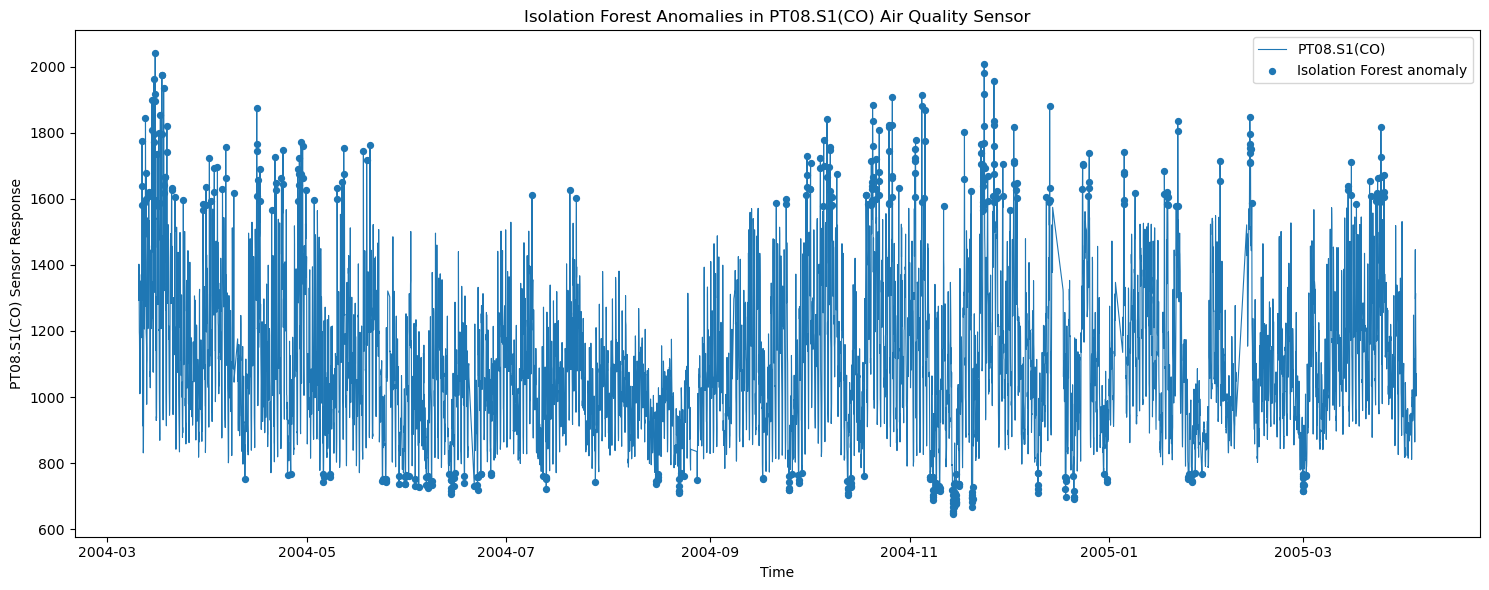

In [37]:
plt.figure(figsize=(15, 6))

plt.plot(
    anomaly_results["timestamp"],
    anomaly_results["sensor_value"],
    linewidth=0.8,
    label="PT08.S1(CO)"
)

plt.scatter(
    detected_anomalies["timestamp"],
    detected_anomalies["sensor_value"],
    s=18,
    label="Isolation Forest anomaly"
)

plt.xlabel("Time")
plt.ylabel("PT08.S1(CO) Sensor Response")
plt.title(
    "Isolation Forest Anomalies in PT08.S1(CO) Air Quality Sensor"
)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Isolation Forest Results

The Isolation Forest results show that unusual observations occur at both the high and low ends of the `PT08.S1(CO)` sensor-response distribution. The 443 detected anomalies had values ranging from 647 to 2,040, while normal observations ranged from 771 to 1,574.

The anomalous observations also showed substantially greater variation, with a standard deviation of approximately 477.21 compared with 189.28 for normal observations. The highest anomaly score was approximately 0.184 and occurred on 15 March 2004 at 19:00, when the sensor response reached 2,040.

The time-series visualisation shows clusters of high-response anomalies as well as periods containing unusually low responses. This indicates that Isolation Forest is detecting observations that differ from the normal distribution rather than simply applying a fixed high-value threshold.

Because this dataset does not contain ground-truth anomaly labels, these observations cannot be confirmed as actual pollution incidents or sensor faults. The results instead demonstrate that the current Models pipeline can identify statistically unusual behaviour in a previously unseen real-world IoT sensor dataset and return the detections through the shared analytics alert format.

## 3.3 Correlation Pipeline Evaluation

The correlation component is evaluated using `PT08.S1(CO)` and `PT08.S5(O3)`. Exploratory analysis identified a strong positive overall Pearson correlation of approximately 0.899 between these two sensor-response variables.

The purpose of this experiment is not only to confirm the overall relationship, but to determine whether the existing Correlation/AIntl component can process the real-world dataset and identify changes in the relationship over rolling time windows.

The existing pipeline is used without modifying the shared correlation implementation. Pearson correlation is evaluated using a window size of 20 observations and a step size of 10 observations, consistent with the existing Analytics Intelligence smoke-test configuration.

In [38]:
from analytics_integration.pipeline import run_correlation_path

correlation_alerts, raw_correlation_result = run_correlation_path(
    df=model_df,
    timestamp_col="timestamp",
    correlation_streams=[
        "PT08.S1(CO)",
        "PT08.S5(O3)"
    ],
    window_size=20,
    step_size=10,
    method="pearson"
)

print("Correlation pipeline completed successfully.")
print("Status:", raw_correlation_result.get("status"))

print(
    "Processed rows:",
    raw_correlation_result.get("summary", {}).get("processed_rows")
)

print("Total correlation alerts:", len(correlation_alerts))

2026-09-01T17:26:45 INFO    correlation.api          request_id=addabb2b event=received source=json rows_in=8991 streams=PT08.S1(CO),PT08.S5(O3) window_size=20 step_size=10 method=pearson
2026-09-01T17:26:46 INFO    correlation.api          request_id=addabb2b event=completed rows_out=8991 windows=898 alerts=27 runtime_ms=1597
Correlation pipeline completed successfully.
Status: success
Processed rows: 8991
Total correlation alerts: 27


In [39]:
print("Raw correlation result keys:")
print(raw_correlation_result.keys())

print("\nSummary:")
print(raw_correlation_result.get("summary"))

print("\nConfiguration:")
print(raw_correlation_result.get("configuration"))

Raw correlation result keys:
dict_keys(['alerts', 'changes', 'configuration', 'correlations', 'data_quality', 'request_id', 'runtime_ms', 'skipped_pairs', 'status', 'summary'])

Summary:
{'alerts': 27, 'changes': 897, 'correlation_results': 898, 'missing_values_imputed': 0, 'non_numeric_values_coerced': 0, 'processed_rows': 8991, 'skipped_pairs': 0, 'windows': 898}

Configuration:
{'delta_threshold': 0.3, 'method': 'pearson', 'step_size': 10, 'strong_corr_threshold': 0.7, 'weak_corr_threshold': 0.4, 'window_size': 20}


In [40]:
import json

if correlation_alerts:
    print("First correlation alert:\n")
    print(json.dumps(correlation_alerts[0], indent=4))
else:
    print(
        "No correlation-change alerts were generated, "
        "but the correlation pipeline completed successfully."
    )

First correlation alert:

{
    "timestamp": "2004-04-04T20:00:00Z",
    "alert_type": "CORRELATION_CHANGE",
    "target": {
        "entity_id": null,
        "metrics": [
            "PT08.S1(CO)",
            "PT08.S5(O3)"
        ]
    },
    "method": "pearson",
    "score": 0.3049594741427304,
    "score_metadata": {
        "type": "absolute_correlation_delta",
        "normalized": false
    },
    "severity": "LOW",
    "message": "Correlation changed by 0.30, classified as LOW severity",
    "time_window": {
        "start": "2004-04-04T01:00:00Z",
        "end": "2004-04-04T20:00:00Z",
        "window_size": 20,
        "step_size": 10
    },
    "supporting_values": {
        "previous_correlation": 0.9478793772453372,
        "current_correlation": 0.6429199031026068,
        "delta": 0.3049594741427304,
        "window_index": 58
    },
    "source": {
        "component": "correlation"
    },
    "alert_id": null
}


### Correlation Pipeline Results

The correlation pipeline successfully processed all 8,991 observations using `PT08.S1(CO)` and `PT08.S5(O3)`.

The main results were:

- Pipeline status: Success
- Rows processed: 8,991
- Correlation method: Pearson
- Window size: 20 observations
- Step size: 10 observations
- Correlation windows analysed: 898
- Correlation changes calculated: 897
- Correlation-change alerts generated: 27
- Missing values imputed: 0
- Non-numeric values coerced: 0
- Skipped sensor pairs: 0
- Runtime: 1,597 ms
- Delta threshold: 0.3
- Strong correlation threshold: 0.7
- Weak correlation threshold: 0.4

The exploratory analysis showed a strong overall positive correlation of approximately 0.899 between the selected sensor variables. However, the rolling correlation analysis generated 27 correlation-change alerts, showing that the relationship between the two sensor streams was not constant across the complete time period.

The first correlation alert occurred on 4 April 2004 at 20:00. It reported an absolute correlation change of approximately 0.305 and was classified as LOW severity.

No missing values required imputation, no non-numeric values were coerced, and no sensor pairs were skipped during execution. This indicates that the preprocessing stage successfully prepared the dataset for the existing correlation pipeline.

## 3.4 Full Analytics Intelligence MVP Pipeline

After evaluating the Models and Correlation components separately, the complete Analytics Intelligence pipeline was tested using the same preprocessed Air Quality dataset.

The purpose of this test is to determine whether a previously unseen real-world IoT dataset can successfully pass through the existing Models and Correlation components and produce a combined Analytics response that follows the Draft V0.1 shared alert contract.

The experiment uses `PT08.S1(CO)` for Isolation Forest anomaly detection and `PT08.S1(CO)` with `PT08.S5(O3)` for rolling Pearson correlation analysis.

In [41]:
from analytics_integration.pipeline import run_analytics_pipeline

final_response = run_analytics_pipeline(
    df=model_df,
    timestamp_col="timestamp",
    entity_id="air_quality_italy",
    model_metric="PT08.S1(CO)",
    correlation_streams=[
        "PT08.S1(CO)",
        "PT08.S5(O3)"
    ],
    detector_name="isolationforest",
    detector_parameters={
        "contamination": 0.05,
        "n_estimators": 100,
        "random_state": 42
    },
    correlation_window_size=20,
    correlation_step_size=10,
    correlation_method="pearson"
)

print("Full AIntl pipeline completed successfully.")
print("Status:", final_response["status"])
print("Processed items:", final_response["summary"]["processed_items"])
print("Total alerts:", final_response["summary"]["alert_count"])
print("Errors:", final_response["errors"])

2026-09-01T17:34:07 INFO    correlation.api          request_id=fd67d9de event=received source=json rows_in=8991 streams=PT08.S1(CO),PT08.S5(O3) window_size=20 step_size=10 method=pearson
2026-09-01T17:34:08 INFO    correlation.api          request_id=fd67d9de event=completed rows_out=8991 windows=898 alerts=27 runtime_ms=1416
Full AIntl pipeline completed successfully.
Status: success
Processed items: 8991
Total alerts: 470
Errors: []


In [42]:
from collections import Counter

alert_type_counts = Counter(
    alert["alert_type"]
    for alert in final_response["alerts"]
)

print("Final alert types:")

for alert_type, count in alert_type_counts.items():
    print(f"{alert_type}: {count}")

Final alert types:
POINTWISE_ANOMALY: 443
CORRELATION_CHANGE: 27


In [43]:
from analytics_validation.response_validator import validate_response

validation_errors = validate_response(final_response)

print("Draft V0.1 validation errors:", validation_errors)

if len(validation_errors) == 0:
    print("Final Analytics response is valid Draft V0.1 JSON.")
else:
    print("Final Analytics response contains validation errors.")

Draft V0.1 validation errors: []
Final Analytics response is valid Draft V0.1 JSON.


### Full Pipeline Results and Interpretation

The complete Analytics Intelligence pipeline successfully processed all 8,991 preprocessed Air Quality observations.

The final response contained 470 alerts in total. Of these, 443 were `POINTWISE_ANOMALY` alerts generated by the Isolation Forest Models path and 27 were `CORRELATION_CHANGE` alerts generated by the correlation path. The pipeline returned a `success` status with no reported errors.

The final response was also checked using the project's Draft V0.1 response validator. No validation errors were returned, confirming that the combined analytics output follows the expected shared JSON contract.

This end-to-end experiment demonstrates that the existing Analytics Intelligence pipeline can process a previously unseen real-world environmental IoT dataset. The Models component successfully identified unusual sensor observations, while the Correlation component identified changes in the relationship between two sensor streams. Both types of results were successfully combined into one valid Analytics response.

These results provide evidence of the MVP's ability to operate beyond its existing test datasets. However, the Air Quality dataset does not contain ground-truth anomaly labels. Therefore, the 443 Isolation Forest alerts should be interpreted as statistically unusual observations rather than confirmed real-world pollution events or sensor faults.

# 4. Professional Evaluation and MVP Assessment

## 4.1 Pipeline Performance

The real-world Air Quality dataset was successfully processed by the existing Models and Analytics Intelligence pipeline. After preprocessing, 8,991 observations were available for evaluation.

Isolation Forest generated 443 pointwise anomaly alerts (4.93%) and completed in approximately 0.161 seconds. The correlation component processed 898 rolling windows and generated 27 correlation-change alerts, with a runtime of approximately 1.4–1.6 seconds.

The complete AIntl pipeline successfully combined both outputs into 470 alerts with no reported errors.

## 4.2 Behaviour and Stability

The pipeline behaved consistently across the separate Models test, Correlation test and complete AIntl execution. Isolation Forest produced the same 443 anomaly alerts when using a fixed `random_state=42`, while the correlation component produced 27 alerts in both the individual and full-pipeline runs.

The final response successfully passed Draft V0.1 validation with zero validation errors. This indicates that the existing adapters and Analytics integration can produce a consistent shared output structure when applied to this real-world IoT dataset.

## 4.3 Limitations and Assumptions

The dataset does not contain ground-truth anomaly labels. Therefore, accuracy, precision, recall and F1-score cannot be calculated, and the detected anomalies should not be considered confirmed pollution events or sensor faults.

Only `PT08.S1(CO)` was used as the primary Isolation Forest variable, while `PT08.S1(CO)` and `PT08.S5(O3)` were selected for correlation analysis. Different sensor combinations or detector parameters may produce different results.

Rows containing missing values in the selected modelling variables were removed rather than interpolated. This retained 96.09% of the usable observations but introduced a small number of gaps in the hourly time series.

## 4.4 Final MVP Assessment

The experiment demonstrates that the current Analytics Intelligence MVP can process a previously unseen real-world environmental IoT dataset using the existing project workflow.

The Models component detected unusual sensor behaviour, the Correlation component identified changes between sensor streams, and both outputs were successfully combined into a valid Draft V0.1 Analytics response.

Overall, the test provides evidence that the current MVP is not limited to the existing project test datasets and can be applied to another real-world time-series sensor dataset. Further evaluation with labelled anomaly datasets and additional sensor combinations would be required to assess detection accuracy and broader generalisability.